In [1]:
# import libraries
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from tensorflow import keras
import keras_tuner as kt
from tensorflow.keras import layers, regularizers
import shutil
import os

# load the data
train_X = pd.read_csv('data/train_X.csv', index_col=0)
train_y = pd.read_csv('data/train_y.csv', index_col=0)
test_X = pd.read_csv('data/test_X.csv', index_col=0)

Inspect Variables & Descriptive Statistics 

In [2]:
# inspect X 
train_X.head(5)

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
2247,7.251153,51.921083,-58.389635,3.255184,27.654863,-0.104062,7.421228,2.150974,-0.385294,5.874683,-0.162073,-90.981115,-3.904283,-3.260125,4.188588,1.599832,14.902995,3.006737,-1.096070
816,561.546314,49.383197,-82.180264,212.208694,14.874882,0.573039,-0.454757,-11.507246,-0.673895,-0.482900,2.573820,3.977701,57.294613,59.415319,-14.181770,-58.285078,1.731263,-0.173237,4.866928
2153,3.176991,4.047675,198.122697,-0.031795,-5.609160,0.270688,9.013148,4.761844,-0.162209,5.002455,0.313917,98.434435,-3.442229,-50.922848,47.704868,41.968650,21.377814,-4.523995,-1.123949
1162,4.921202,37.843248,-64.065346,-2.396584,20.127733,-1.303227,7.597263,2.581991,0.202523,-1.808456,-1.531472,-65.145109,-3.358736,-41.952477,41.554045,30.415441,18.108487,1.446456,-0.184203
480,524.827753,51.046876,-51.283559,202.486337,29.323544,1.270929,2.092076,-9.902368,-1.978757,-0.134721,-0.765519,-84.410329,60.194127,57.161506,-14.775510,-61.650444,1.070161,2.408323,3.341689


In [3]:
train_X.info()

<class 'pandas.DataFrame'>
Index: 1875 entries, 2247 to 730
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1       1875 non-null   float64
 1   2       1875 non-null   float64
 2   3       1875 non-null   float64
 3   4       1875 non-null   float64
 4   5       1875 non-null   float64
 5   6       1875 non-null   float64
 6   7       1875 non-null   float64
 7   8       1875 non-null   float64
 8   9       1875 non-null   float64
 9   10      1875 non-null   float64
 10  11      1875 non-null   float64
 11  12      1875 non-null   float64
 12  13      1875 non-null   float64
 13  14      1875 non-null   float64
 14  15      1875 non-null   float64
 15  16      1875 non-null   float64
 16  17      1875 non-null   float64
 17  18      1875 non-null   float64
 18  19      1875 non-null   float64
dtypes: float64(19)
memory usage: 293.0 KB


In [4]:
train_X.describe()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
count,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000,1875.000000
mean,188.549623,35.681131,-23.020111,79.535300,6.494400,0.017679,1.575821,-6.371566,0.003765,3.008358,-0.007331,0.511283,18.935639,0.623234,14.502929,-0.563968,14.958750,-0.040147,0.001789
std,214.007628,14.843754,75.189907,87.294153,12.972696,1.983725,3.348865,8.024242,1.995029,4.980163,2.085640,62.279600,22.448101,47.001243,27.054329,39.643523,6.670035,2.002819,2.029844
min,-4.948336,0.797478,-88.593882,-9.332143,-12.649900,-7.951762,-6.446722,-21.751203,-6.120152,-5.602347,-6.517974,-102.727616,-7.115838,-65.113134,-20.723182,-67.263380,-0.846912,-7.013980,-7.534900
25%,0.705306,25.180712,-76.212654,-1.082576,-4.744640,-1.325778,-0.665431,-14.100780,-1.328670,-0.388653,-1.365419,-56.538464,-0.850952,-48.956833,-10.595039,-38.649198,9.990002,-1.381744,-1.272092
50%,39.813695,37.768074,-59.195916,17.096138,0.379229,0.083334,0.969077,-5.026606,-0.024113,1.844834,0.009696,0.401216,4.026697,4.476561,-0.625250,-2.494332,14.807075,-0.018536,0.050331
75%,415.176709,48.665030,7.010954,174.523568,19.194284,1.310789,3.070437,1.072626,1.355308,5.016684,1.383057,58.888833,40.837936,49.135253,44.731448,37.609661,19.713494,1.285545,1.385280
max,628.476735,61.034331,255.417683,230.648598,32.109396,8.249510,16.586433,9.753831,7.188408,26.709653,6.897172,103.370897,81.617457,65.007552,59.411019,67.043639,32.011020,6.199378,5.795511


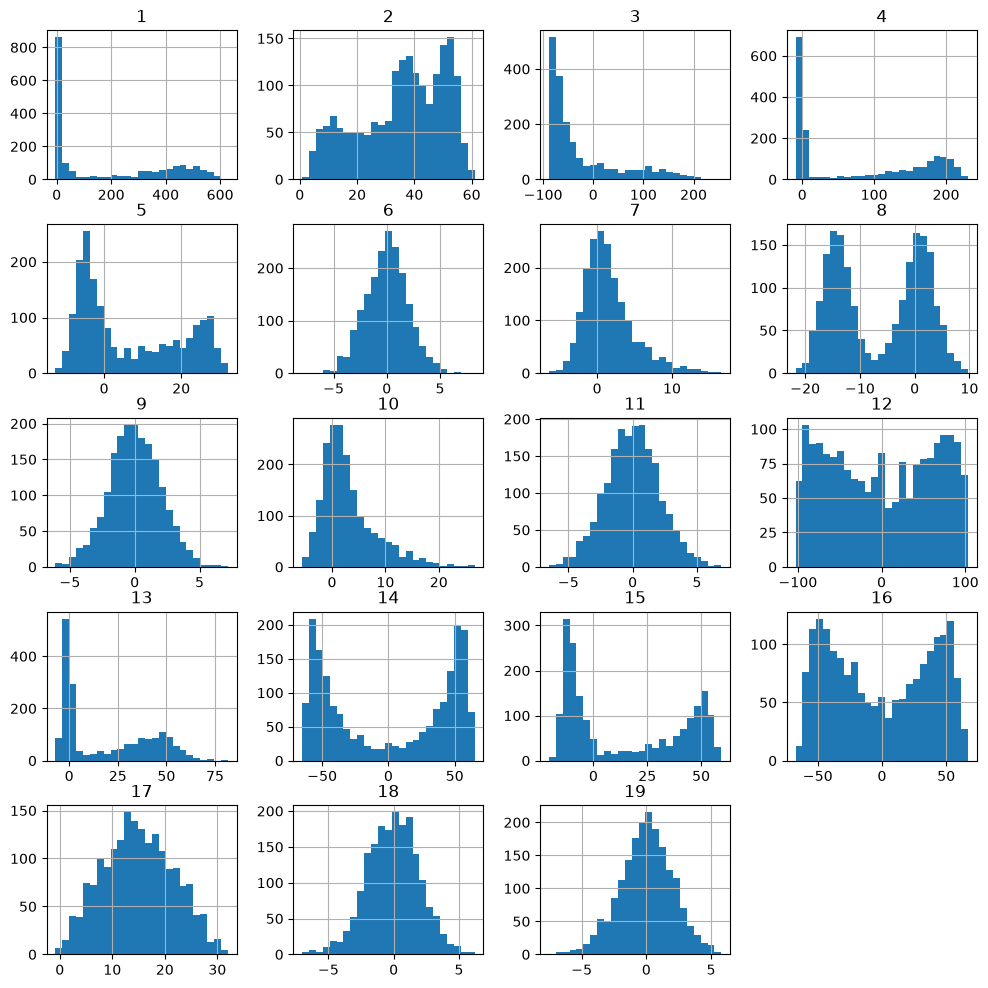

In [5]:
train_X.hist(figsize=(12, 12), bins=25);

In [6]:
# look for missing values in train_X
n_missing_X = train_X.isnull().sum().sum()  
print('Total number of missing values is {}'.format(n_missing_X))

Total number of missing values is 0


In [7]:
# inspect y 
train_y.head(5)

,0
2247,-194.951640
816,-234.872266
2153,912.818343
1162,-136.422539
480,-223.922968


In [8]:
train_y.info()

<class 'pandas.DataFrame'>
Index: 1875 entries, 2247 to 730
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1875 non-null   float64
dtypes: float64(1)
memory usage: 29.3 KB


In [9]:
train_y.describe()

,0
count,1875.000000
mean,0.258640
std,309.484750
min,-251.717141
25%,-234.465358
50%,-143.866546
75%,129.263515
max,999.545992


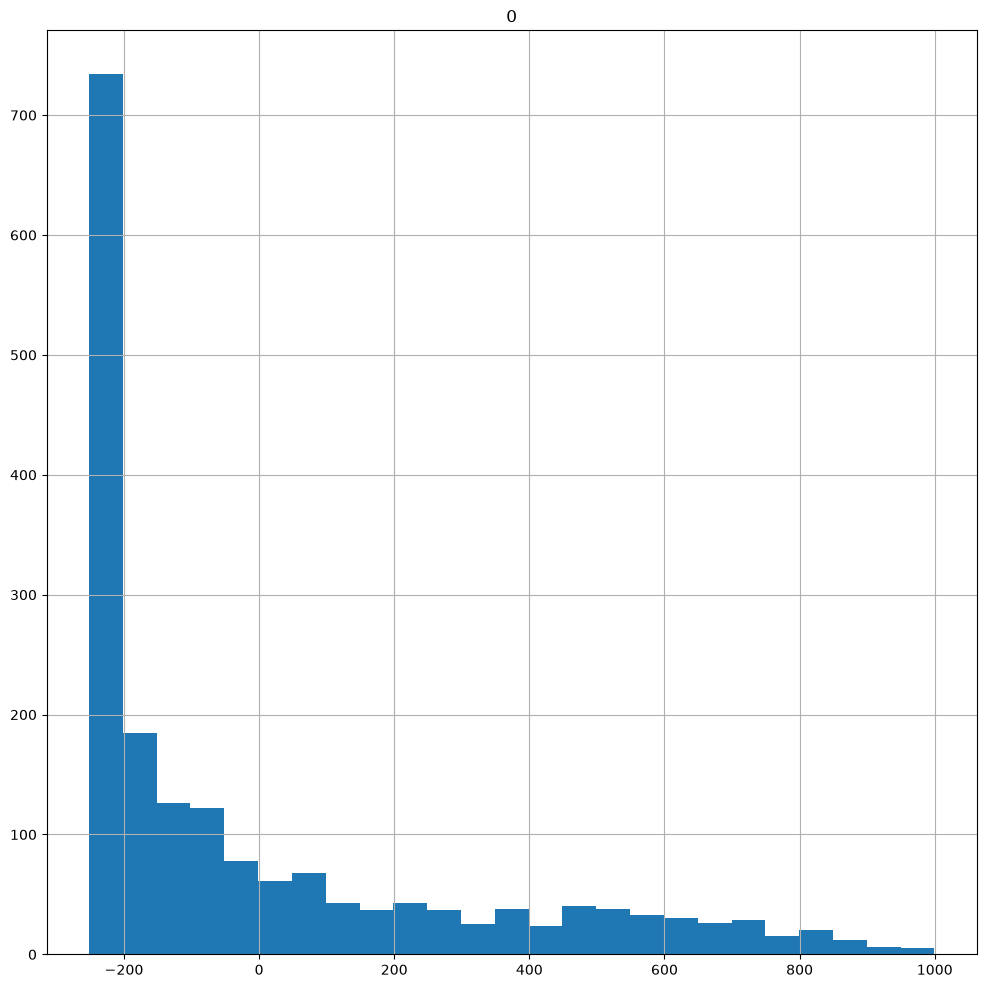

In [10]:
train_y.hist(figsize=(12, 12), bins=25);

In [11]:
# look for missing values in y 
n_missing_y = train_y.isnull().sum().sum()
print('Total number of missing values is {}'.format(n_missing_y))

Total number of missing values is 0


In [12]:
# inspect test set
test_X.head(5)

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
1475,417.981627,32.950757,-47.359228,190.544723,-8.439060,0.047355,-3.058026,-16.480185,-1.946717,-0.271363,-1.552223,90.710554,42.345973,54.594208,-10.575079,-47.350739,7.438208,-2.892835,2.284476
1558,418.531310,32.286813,-42.250539,191.019750,-6.015734,1.975388,0.277463,-15.561488,-1.450490,-1.388994,-1.692642,82.319211,34.903555,53.568401,-8.690446,-41.235706,9.636804,-2.249413,1.778437
981,199.119440,47.811812,-70.763684,103.729008,6.781744,2.066364,1.149377,-16.937419,-0.589804,1.014125,0.047707,9.484637,32.951302,29.503198,-7.979232,-18.520487,12.908520,-0.140195,1.384526
2216,473.943727,49.246582,-81.868840,179.821970,18.255143,-1.249449,-1.477970,-16.966947,-0.516464,0.526311,-0.985130,-29.109660,38.490560,50.501709,-10.637218,-44.221293,9.091748,0.612301,1.399403
1767,39.894121,46.068555,-81.064124,-2.295597,19.608791,0.447590,0.316095,2.362231,0.738051,6.502529,-1.014150,-95.537166,-2.099470,-53.537344,48.036934,47.101212,21.753112,3.196181,-1.407074


In [13]:
test_X.info()

<class 'pandas.DataFrame'>
Index: 625 entries, 1475 to 609
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1       625 non-null    float64
 1   2       625 non-null    float64
 2   3       625 non-null    float64
 3   4       625 non-null    float64
 4   5       625 non-null    float64
 5   6       625 non-null    float64
 6   7       625 non-null    float64
 7   8       625 non-null    float64
 8   9       625 non-null    float64
 9   10      625 non-null    float64
 10  11      625 non-null    float64
 11  12      625 non-null    float64
 12  13      625 non-null    float64
 13  14      625 non-null    float64
 14  15      625 non-null    float64
 15  16      625 non-null    float64
 16  17      625 non-null    float64
 17  18      625 non-null    float64
 18  19      625 non-null    float64
dtypes: float64(19)
memory usage: 97.7 KB


In [14]:
test_X.describe()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
count,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000
mean,181.742434,35.792912,-22.734027,76.136228,6.923616,-0.017042,1.482314,-6.138505,0.049592,2.997339,-0.022991,-2.742762,18.169299,-0.605884,15.090786,0.602799,15.169007,0.101494,-0.061390
std,210.182131,15.294207,78.521521,85.557400,12.899100,2.075806,3.504476,7.843939,2.039532,4.834085,1.929174,63.589723,22.216821,46.359392,26.899038,38.761789,6.396880,2.105305,1.944818
min,-6.275078,3.150672,-87.608096,-6.527035,-12.114083,-6.988169,-5.940716,-21.191053,-6.309831,-5.124562,-5.587574,-101.459417,-6.390900,-64.107870,-17.351661,-64.945371,-1.220024,-5.844904,-5.687520
25%,0.444875,24.629548,-77.208503,-0.943317,-4.558596,-1.482109,-0.896765,-14.019110,-1.385301,-0.267655,-1.342058,-62.486163,-0.892634,-49.627780,-10.460671,-37.347808,10.536986,-1.321774,-1.346835
50%,39.085881,38.677729,-61.260637,10.157443,2.514521,-0.043509,0.984338,-3.736022,0.049291,1.619780,-0.021817,-3.682942,3.108757,2.525675,0.582010,-0.876636,15.004252,0.078322,-0.025467
75%,413.140853,48.705006,3.742664,170.312923,19.120419,1.324594,3.046748,0.933476,1.470479,4.968297,1.301517,56.942732,39.820164,47.992130,45.432944,38.701107,19.970510,1.513625,1.240402
max,603.539091,60.298601,241.817528,226.876660,31.643371,5.995139,17.611829,9.386121,7.452831,24.160214,6.005449,99.891269,68.592653,63.112340,58.836315,65.259033,32.435432,6.570184,5.058142


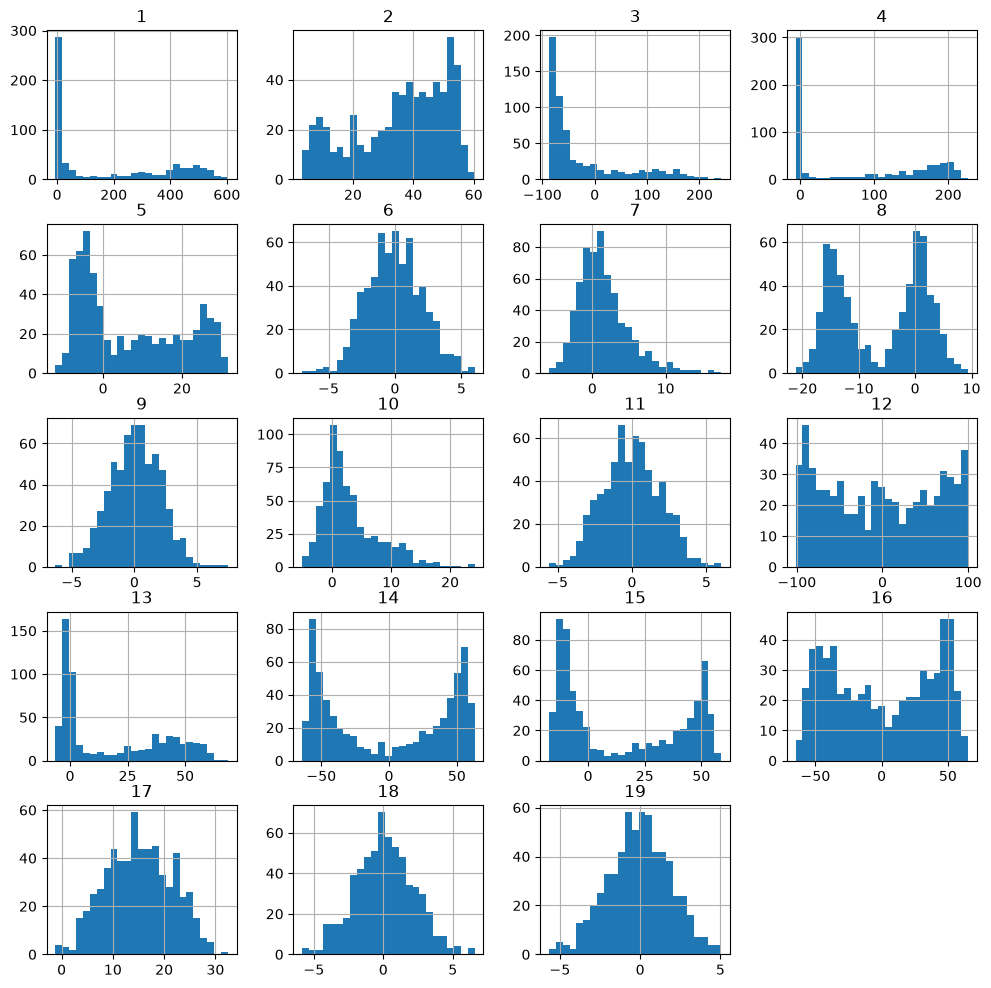

In [15]:
test_X.hist(figsize=(12, 12), bins=25);

In [16]:
# look for missing values in test set
n_missing_test = test_X.isnull().sum().sum()
print('Total number of missing values in test set is {}'.format(n_missing_test))

Total number of missing values in test set is 0


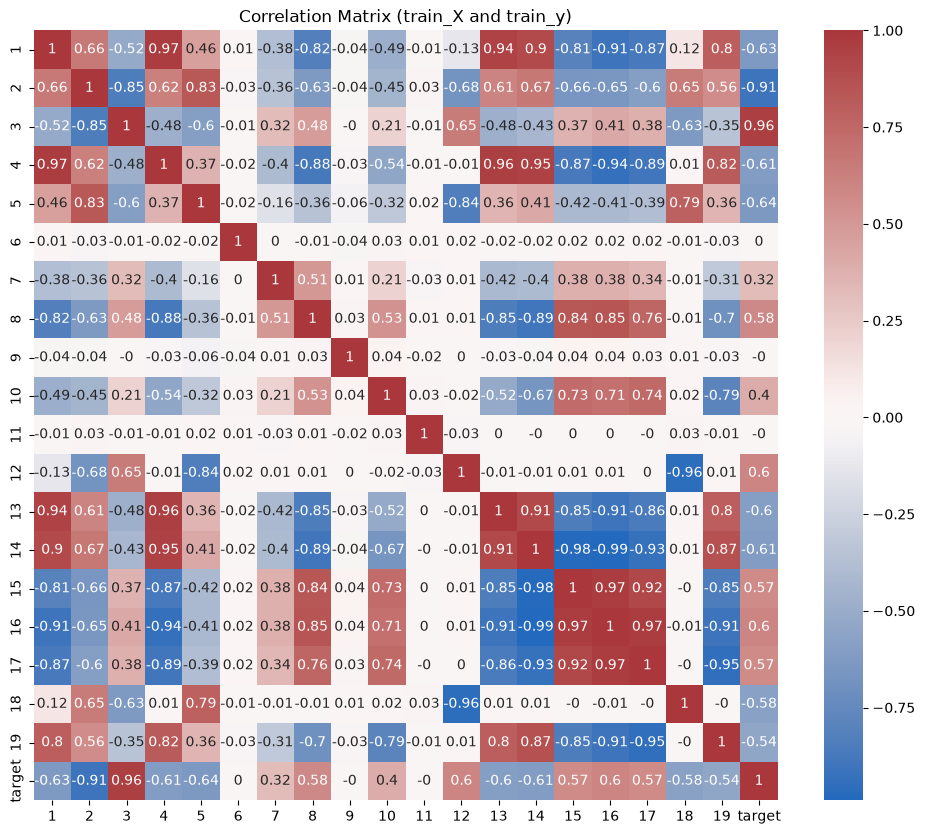

In [17]:
# correlation matrix for X and y
# combine train_X and train_y into one dataframe
train_data = pd.concat([train_X, train_y.iloc[:, 0].rename('target')], axis=1)

# compute the correlation matrix
corr_matrix = train_data.corr().round(2)

# plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='vlag', annot=True)
plt.title('Correlation Matrix (train_X and train_y)')
plt.show()

In [18]:
# correlations of features with target
print(corr_matrix['target'].iloc[:-1])

1    -0.63
2    -0.91
3     0.96
4    -0.61
5    -0.64
6     0.00
7     0.32
8     0.58
9    -0.00
10    0.40
11   -0.00
12    0.60
13   -0.60
14   -0.61
15    0.57
16    0.60
17    0.57
18   -0.58
19   -0.54
Name: target, dtype: float64


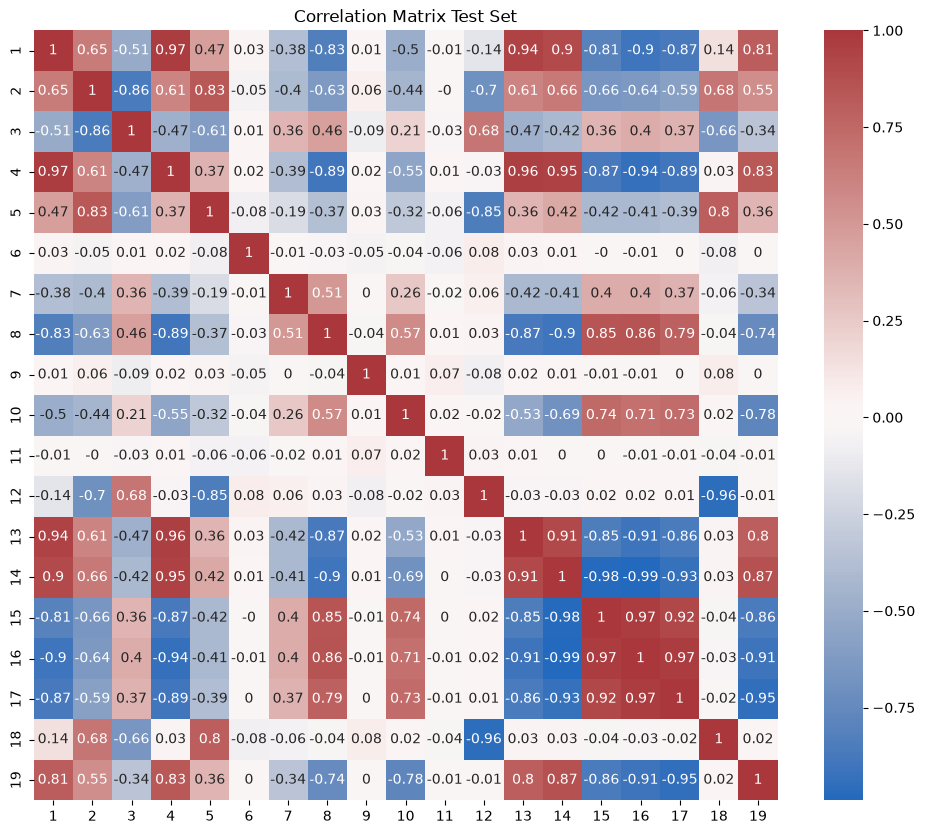

In [19]:
# correlation matrix for test set
corr_matrix_test = test_X.corr().round(2)

# plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_test, cmap='vlag', annot=True)
plt.title('Correlation Matrix Test Set')
plt.show()

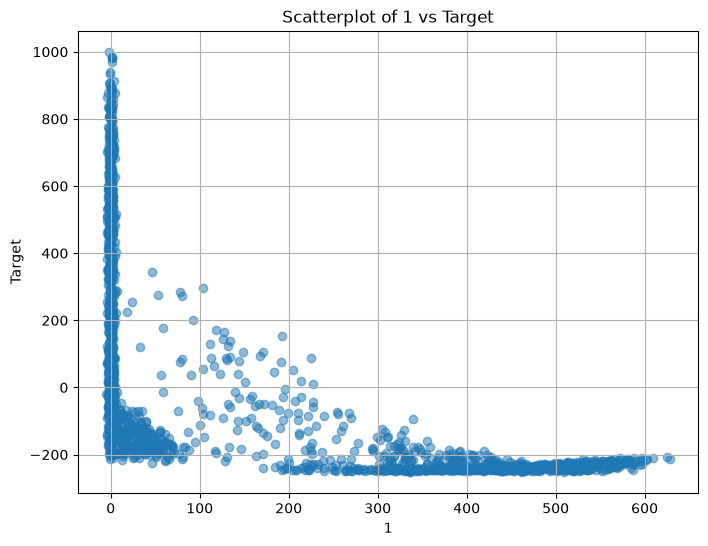

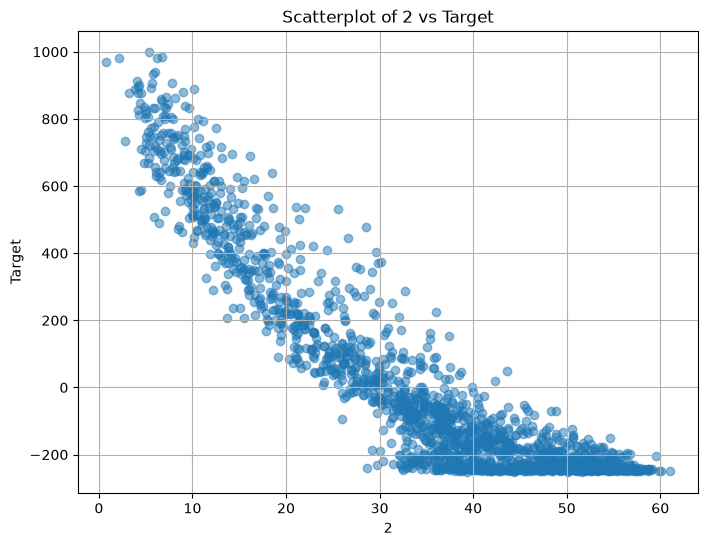

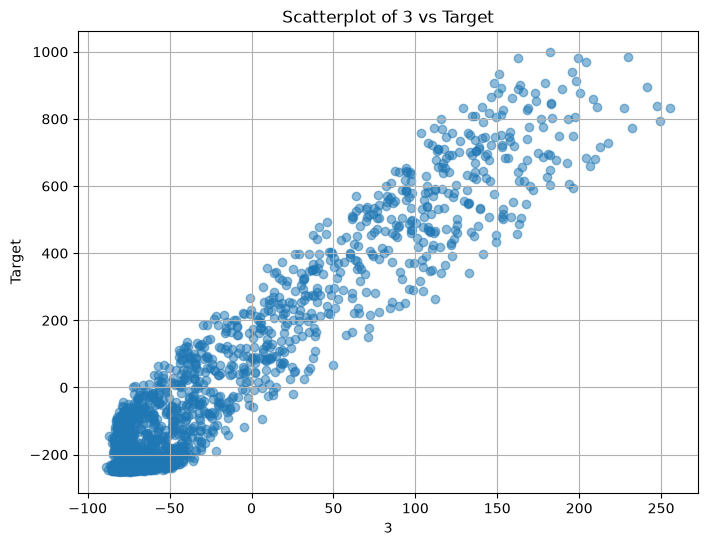

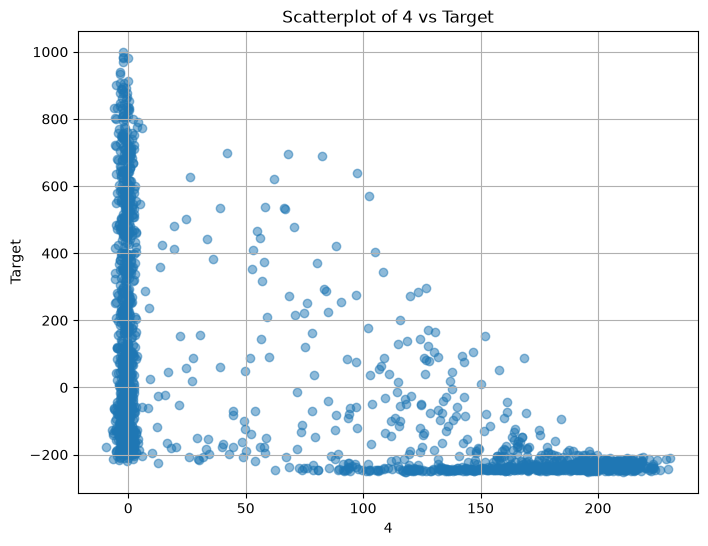

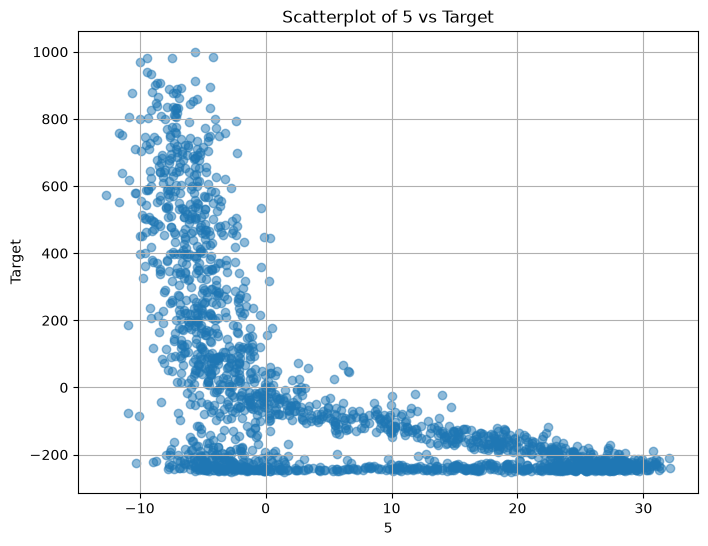

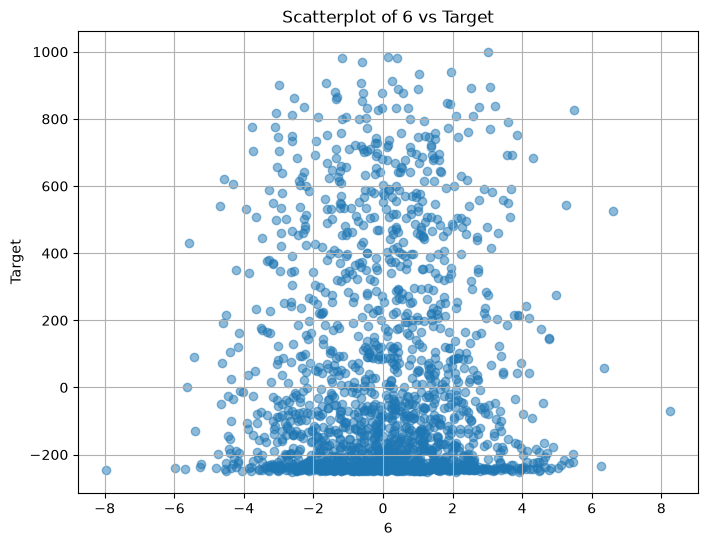

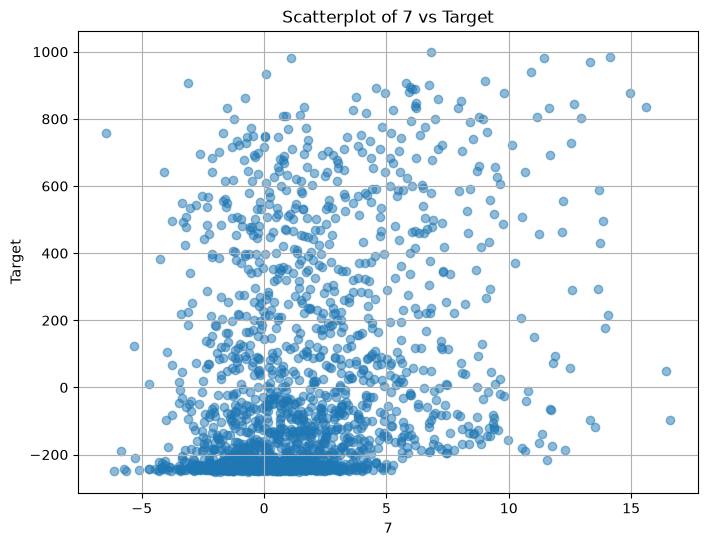

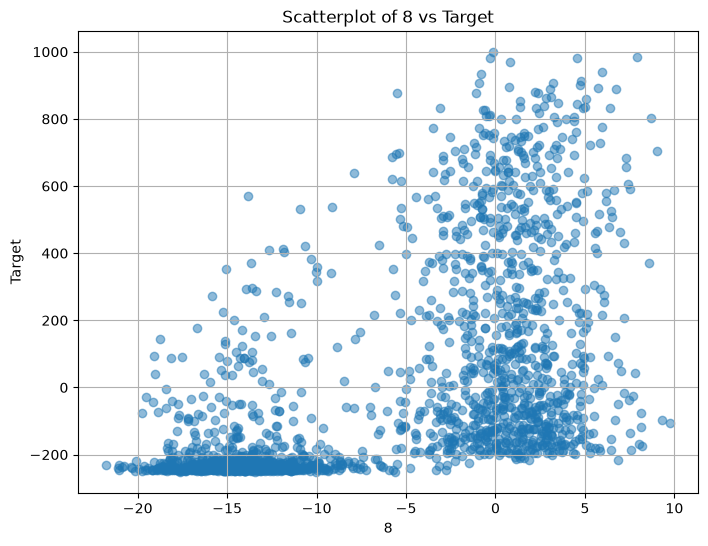

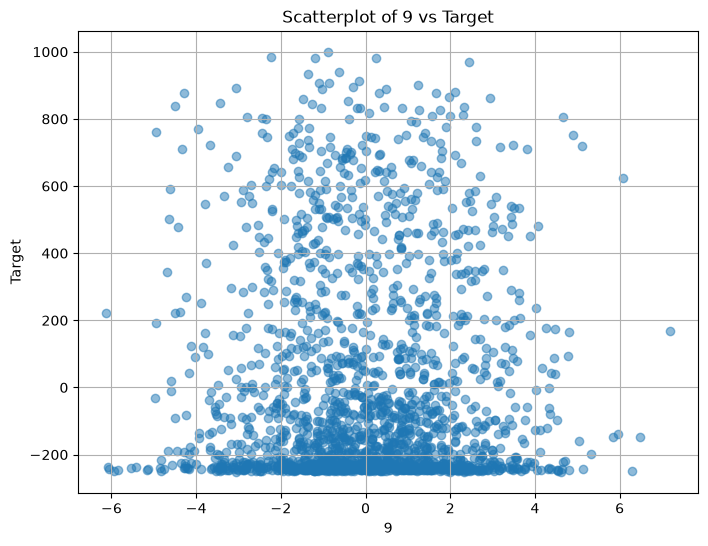

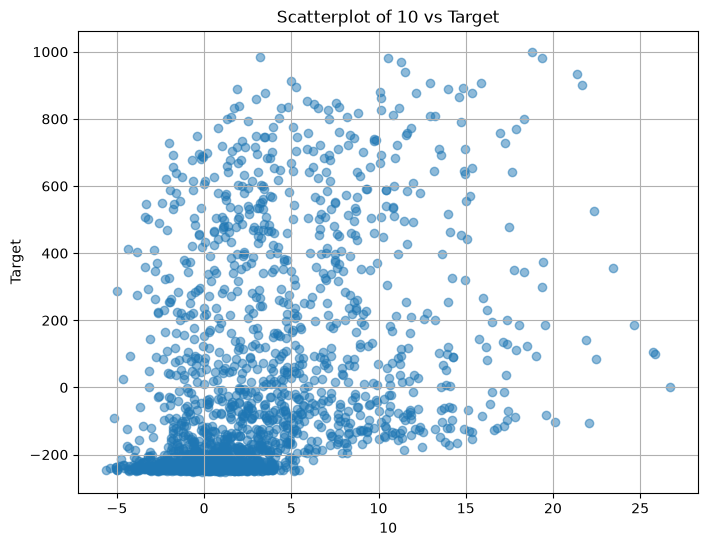

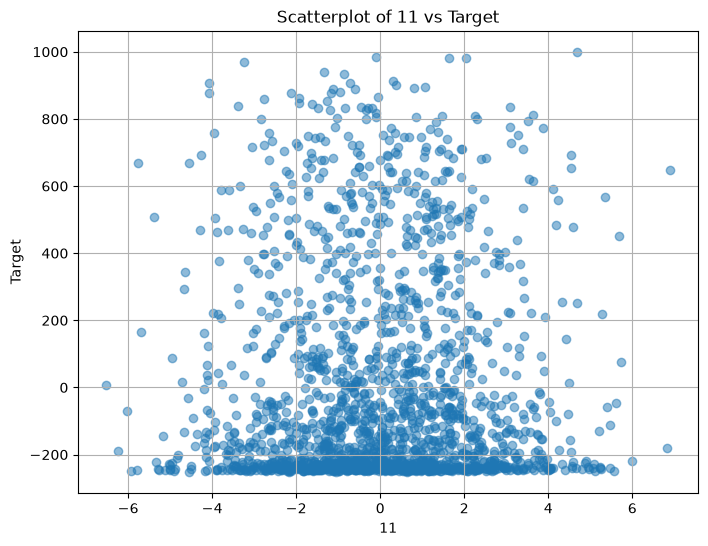

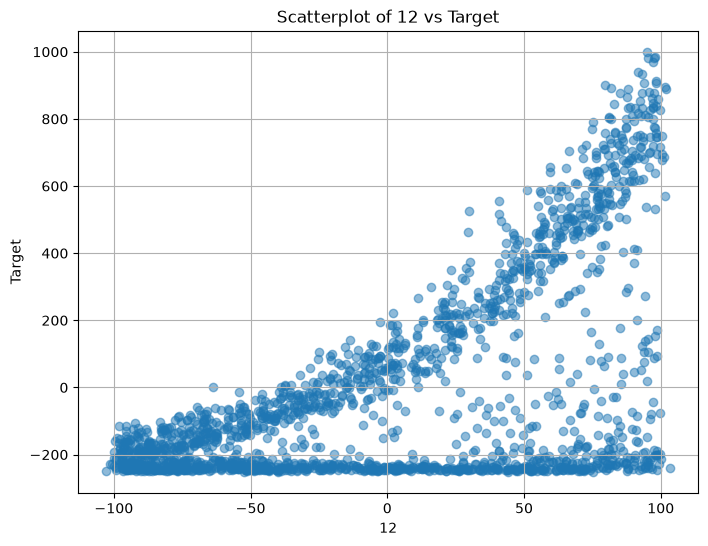

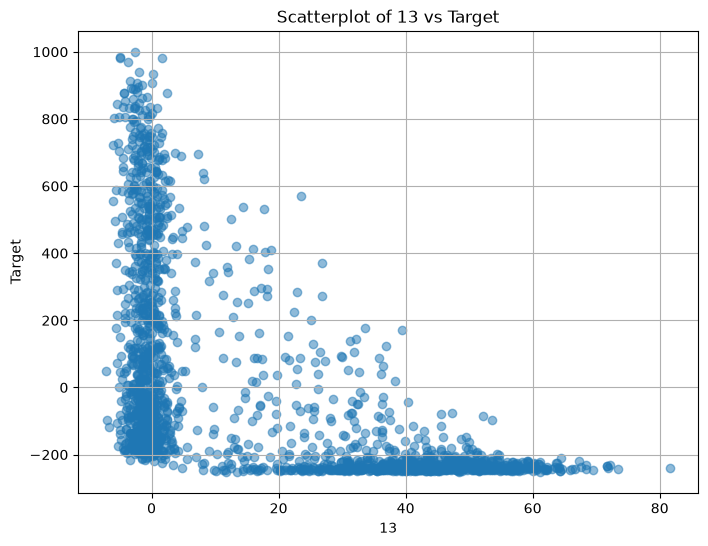

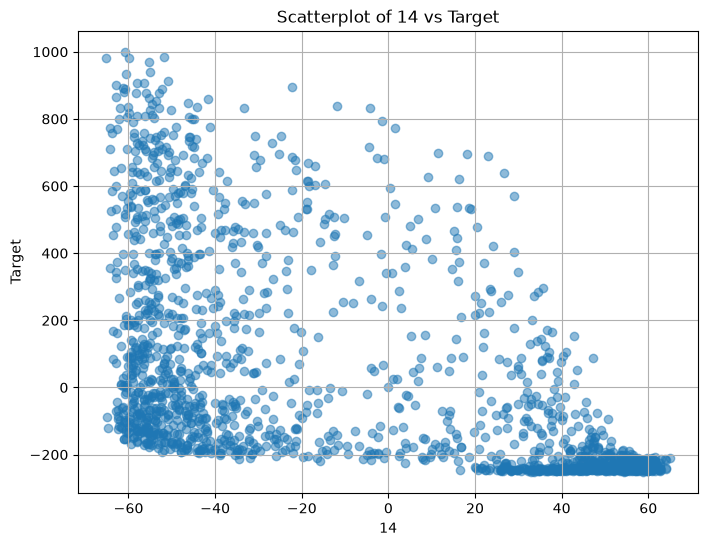

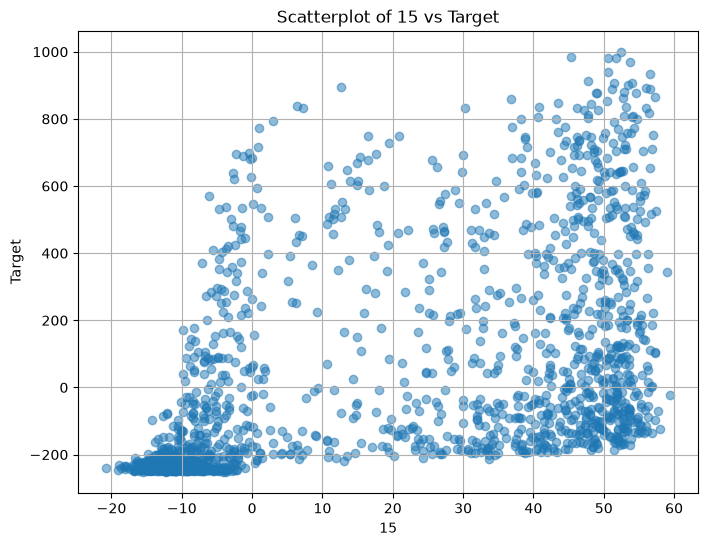

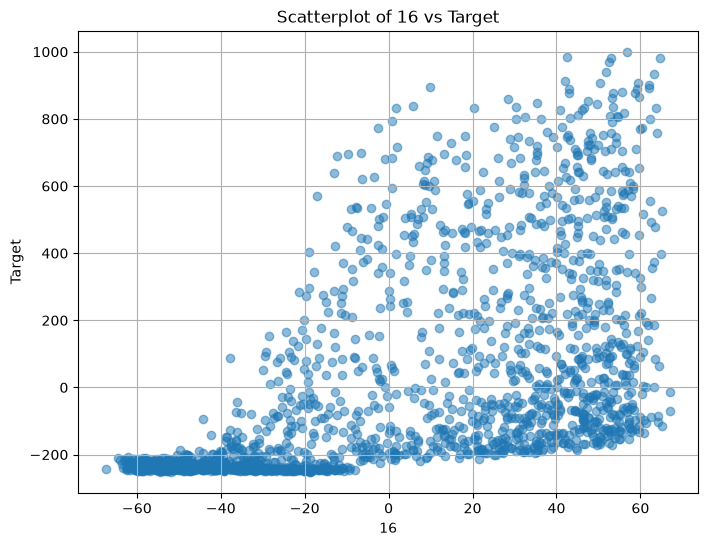

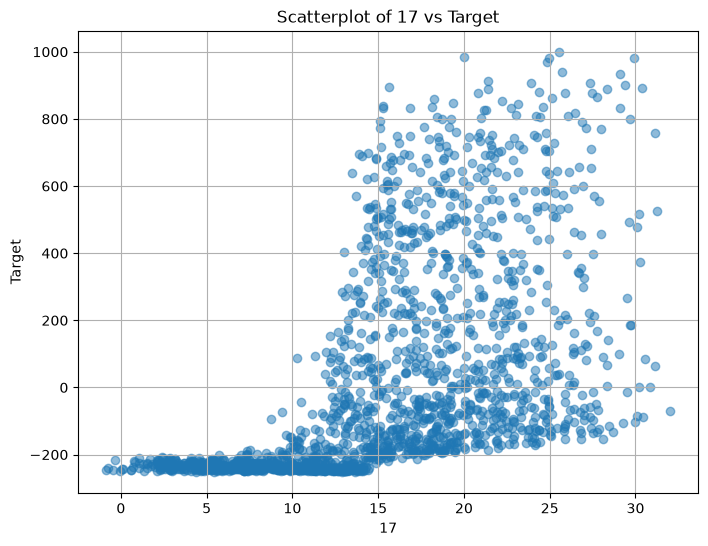

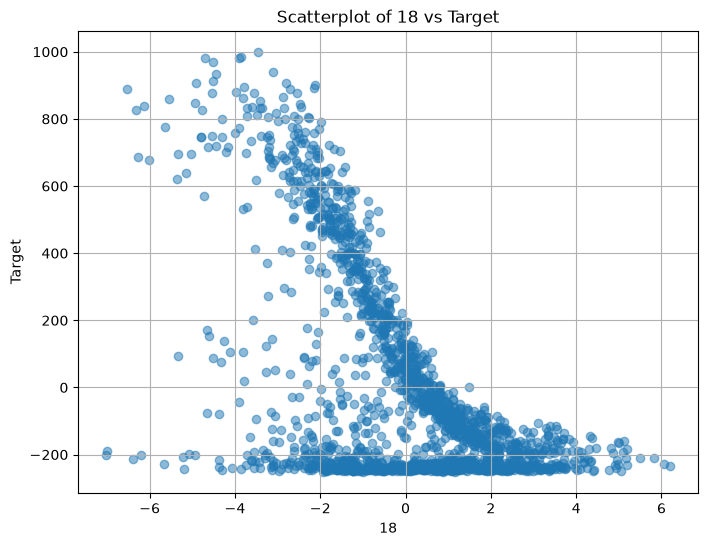

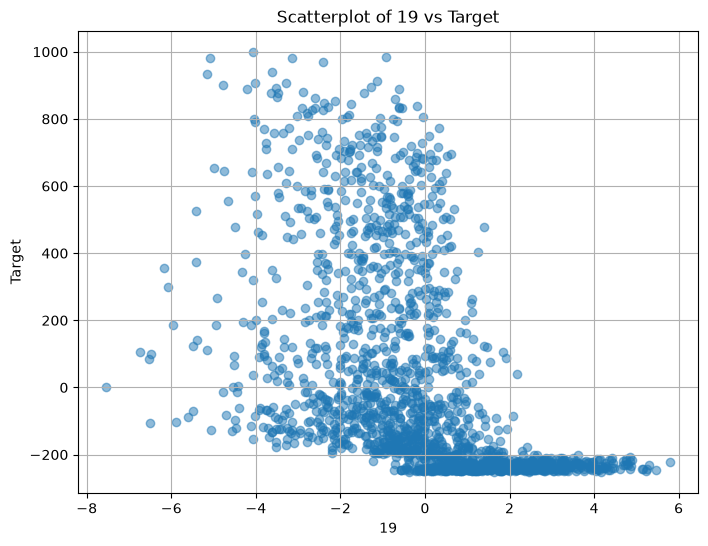

In [20]:
# plot Scatterplots for each feature against the target variable
for column in train_X.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(train_X[column], train_y.iloc[:, 0], alpha=0.5)
    plt.title(f'Scatterplot of {column} vs Target')
    plt.xlabel(column)
    plt.ylabel('Target')
    plt.grid()
    plt.show()

Split Dataset into Training and Validation Subset & Variable Scaling

In [21]:
# split features and target
train_X_raw, val_X_raw, train_y_raw, val_y_raw = train_test_split(
    train_X, train_y, test_size=0.2, random_state=42
)

# scale features
sc_X = RobustScaler()

train_X_sc = pd.DataFrame(
    sc_X.fit_transform(train_X_raw),
    columns=train_X.columns,
    index=train_X_raw.index
)

val_X_sc = pd.DataFrame(
    sc_X.transform(val_X_raw),
    columns=train_X.columns,
    index=val_X_raw.index
)

# scale target
sc_y = RobustScaler()

train_y_sc = pd.DataFrame(
    sc_y.fit_transform(train_y_raw),
    columns=train_y.columns,
    index=train_y_raw.index
)

val_y_sc = pd.DataFrame(
    sc_y.transform(val_y_raw),
    columns=train_y.columns,
    index=val_y_raw.index
)

# scale test features
test_X_sc = pd.DataFrame(
    sc_X.transform(test_X),
    columns=test_X.columns,
    index=test_X.index
)

# separate data for neural network training and tuning
nn_train_X, nn_tune_X, nn_train_y, nn_tune_y = train_test_split(
    train_X_sc,
    train_y_sc,
    test_size=0.2,
    random_state=123
)

In [22]:
# explore train_X again after scaling 
train_X_sc.describe()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
count,1.500000e+03,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1.500000e+03,1.500000e+03,1.500000e+03,1500.000000,1.500000e+03,1500.000000,1500.000000,1.500000e+03,1.500000e+03,1.500000e+03
mean,3.604798e-01,-0.093220,0.433523,0.344859,0.255878,-0.027871,0.172745,-0.090088,0.007459,2.279894e-01,2.309671e-03,-4.252097e-03,0.357079,-4.283122e-02,0.270498,0.023364,1.162191e-02,-8.450179e-03,-1.580718e-02
std,5.194591e-01,0.631048,0.910790,0.495960,0.541102,0.760428,0.900001,0.530557,0.745703,9.312514e-01,7.613937e-01,5.474569e-01,0.535568,4.785196e-01,0.489222,0.521722,6.952416e-01,7.575202e-01,7.650567e-01
min,-1.082245e-01,-1.575935,-0.367658,-0.146939,-0.535453,-3.071601,-1.991532,-1.102457,-2.236194,-1.384399e+00,-2.375203e+00,-9.300346e-01,-0.266099,-7.176863e-01,-0.363907,-0.817866,-1.639850e+00,-2.652342e+00,-2.585525e+00
25%,-9.458460e-02,-0.550483,-0.215388,-0.113106,-0.206744,-0.533907,-0.424029,-0.598975,-0.487989,-4.134277e-01,-4.883759e-01,-4.991057e-01,-0.118148,-5.487745e-01,-0.180236,-0.474096,-5.007320e-01,-5.138418e-01,-4.917895e-01
50%,8.646512e-18,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.103352e-17,-2.710505e-19,-2.059984e-18,0.000000,4.553649e-18,0.000000,0.000000,-9.302455e-17,-1.301043e-18,2.602085e-18
75%,9.054154e-01,0.449517,0.784612,0.886894,0.793256,0.466093,0.575971,0.401025,0.512011,5.865723e-01,5.116241e-01,5.008943e-01,0.881852,4.512255e-01,0.819764,0.525904,4.992680e-01,4.861582e-01,5.082105e-01
max,1.431272e+00,0.990894,3.729216,1.202787,1.338470,3.106662,4.228508,0.973764,2.638669,4.554203e+00,2.502873e+00,8.926360e-01,1.850808,6.122367e-01,1.089162,0.920693,1.803869e+00,2.384813e+00,2.175928e+00


In [23]:
# explore train_y again after scaling
train_y_sc.describe()

,0
count,1.500000e+03
mean,4.000580e-01
std,8.605282e-01
min,-3.030585e-01
25%,-2.537113e-01
50%,3.946496e-17
75%,7.462887e-01
max,3.178477e+00


In [24]:
# explore test_X again after scaling
test_X_sc.describe()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
count,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000
mean,0.345515,-0.084700,0.431267,0.325139,0.284025,-0.045740,0.149682,-0.073560,0.023754,0.238323,-0.013468,-0.045800,0.337128,-0.058378,0.285506,0.042473,0.038720,0.060197,-0.047747
std,0.510833,0.651721,0.952519,0.485976,0.540043,0.791597,0.946374,0.516925,0.747071,0.912170,0.701495,0.562368,0.530026,0.473825,0.487759,0.512357,0.670433,0.802578,0.738384
min,-0.111449,-1.475660,-0.355699,-0.144398,-0.513020,-2.704140,-1.854887,-1.065542,-2.305672,-1.294243,-2.036887,-0.918819,-0.248804,-0.707412,-0.302771,-0.823949,-1.678954,-2.206671,-2.183805
25%,-0.095117,-0.560396,-0.229545,-0.112682,-0.196697,-0.604435,-0.492782,-0.592902,-0.501840,-0.377766,-0.493113,-0.574152,-0.117632,-0.559415,-0.177817,-0.459162,-0.446745,-0.482377,-0.535788
50%,-0.001202,0.038228,-0.036087,-0.049628,0.099431,-0.055833,0.015205,0.084766,0.023644,-0.021616,-0.013041,-0.054115,-0.022171,-0.026371,0.022419,0.022917,0.021453,0.051363,-0.034108
75%,0.907913,0.465513,0.752447,0.860073,0.794665,0.465885,0.572153,0.392492,0.544218,0.610234,0.468155,0.482040,0.853652,0.438327,0.835699,0.546059,0.541948,0.598525,0.446502
max,1.370663,0.959543,3.640456,1.181362,1.318959,2.246971,4.505413,0.949532,2.735526,4.231662,2.178621,0.861863,1.540076,0.592866,1.078741,0.897104,1.848350,2.526171,1.895973


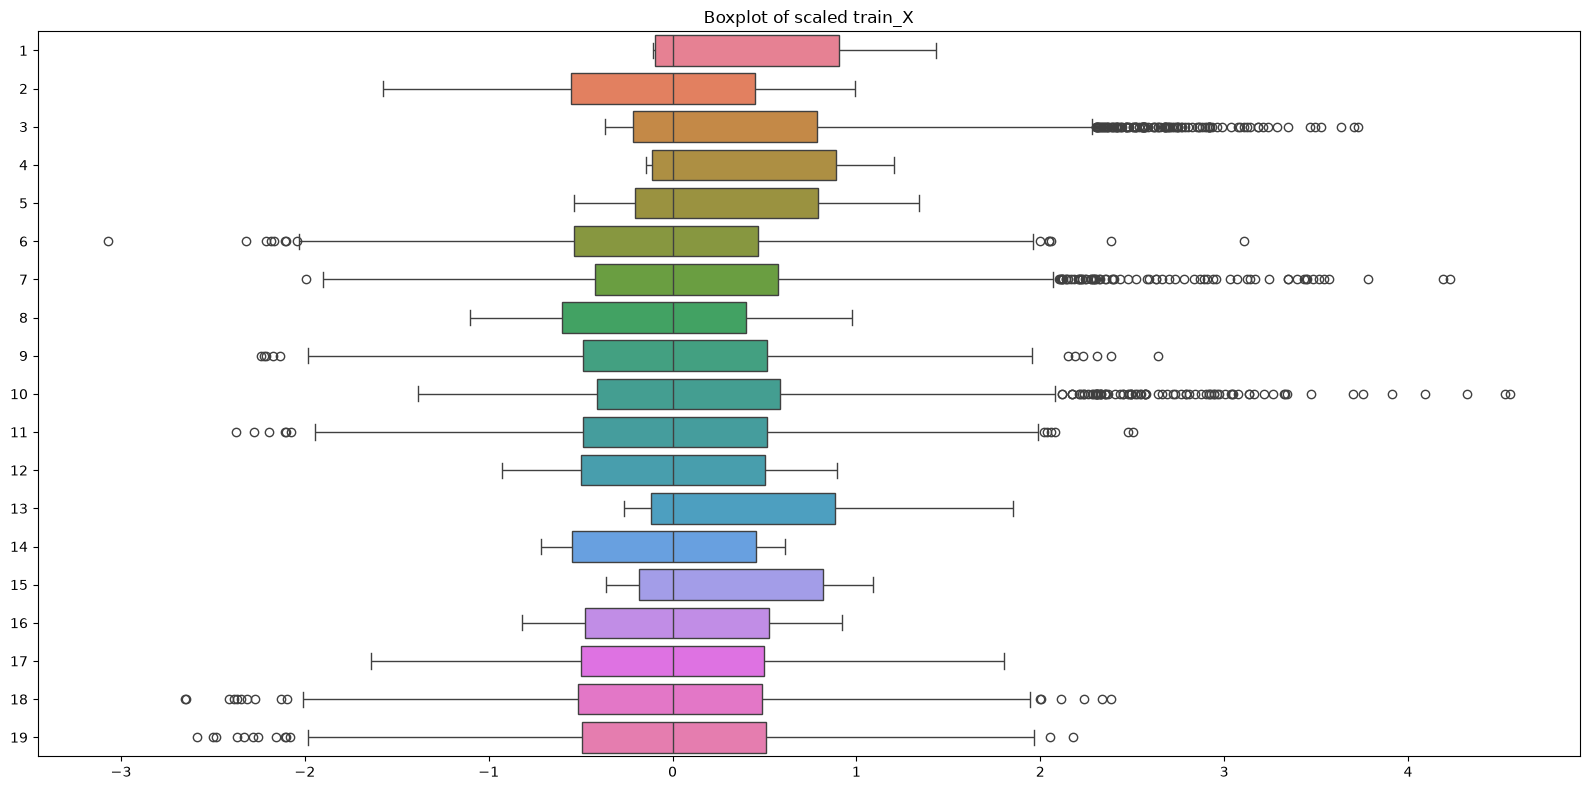

In [25]:
# detect outliers with boxplots
# boxplots for train_X
plt.figure(figsize=(16, 8))
sns.boxplot(data=train_X_sc, orient="h")
plt.title("Boxplot of scaled train_X")
plt.tight_layout()
plt.show()

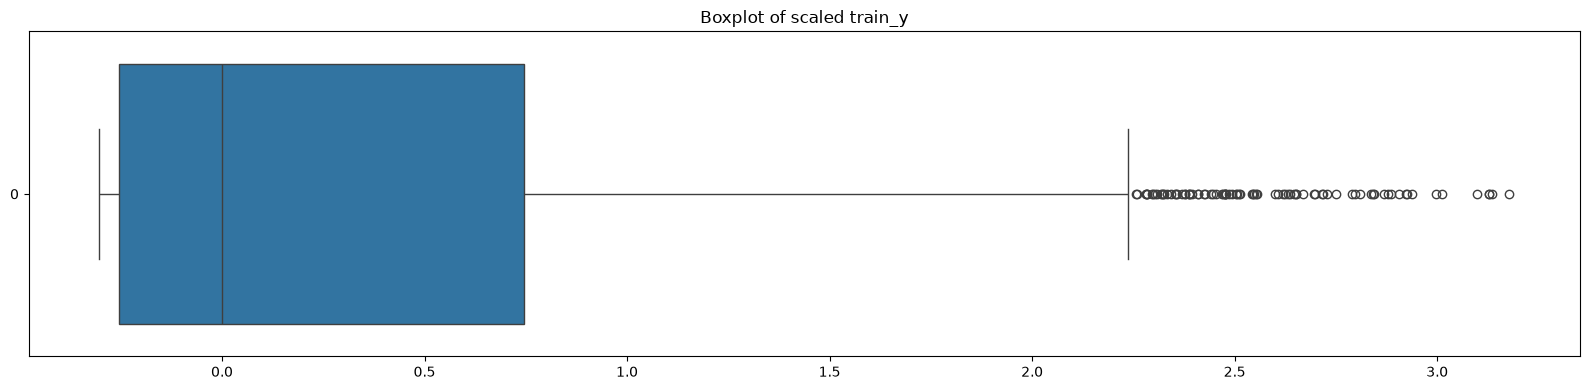

In [26]:
# boxplots for train_y
plt.figure(figsize=(16, 4))
sns.boxplot(data=train_y_sc, orient="h")
plt.title("Boxplot of scaled train_y")
plt.tight_layout()  
plt.show()

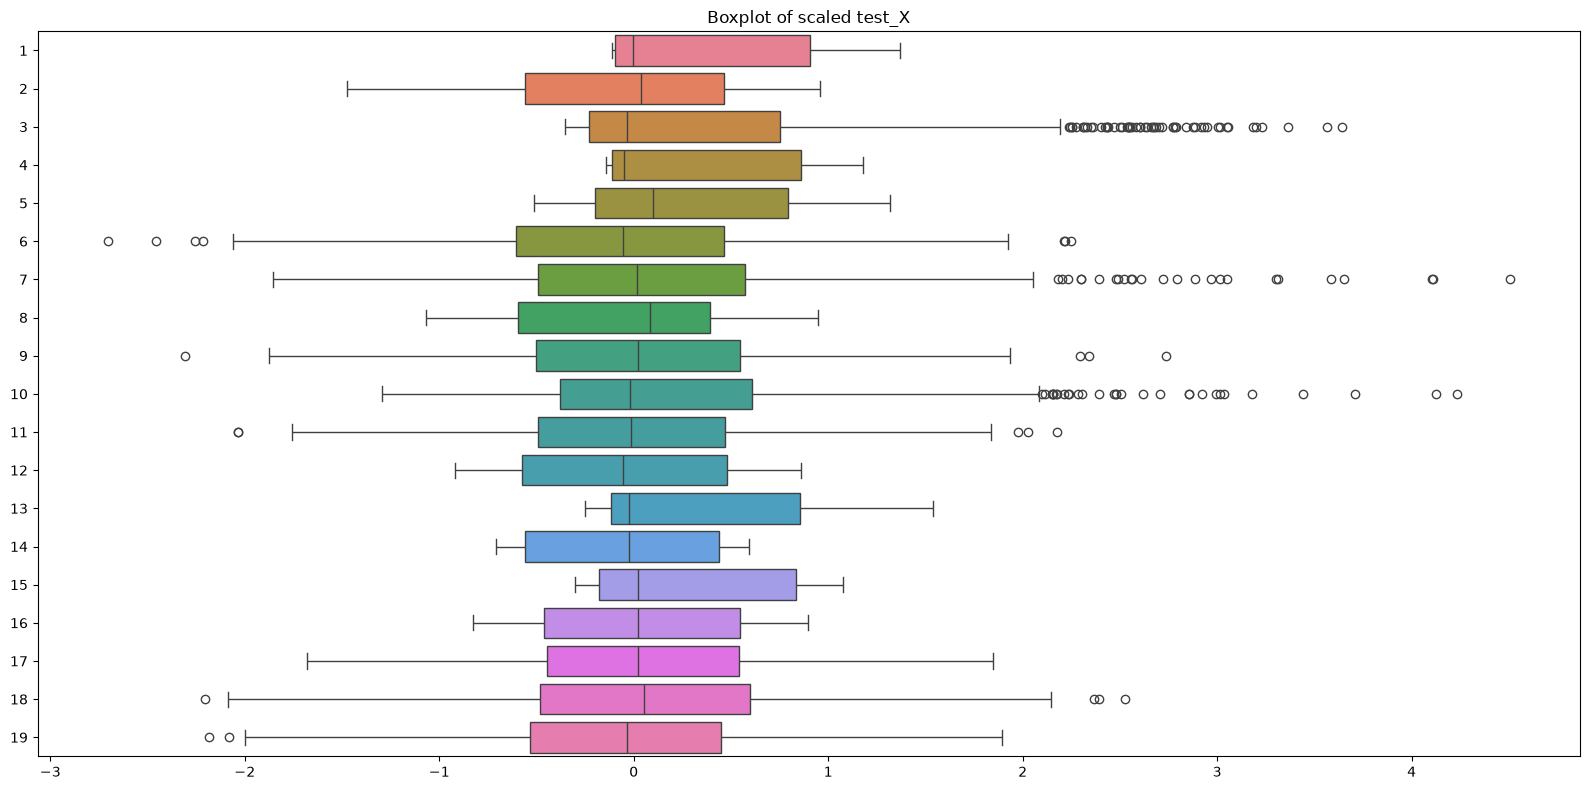

In [27]:
# boxplot for test_X
plt.figure(figsize=(16, 8))
sns.boxplot(data=test_X_sc, orient="h")
plt.title("Boxplot of scaled test_X")
plt.tight_layout()
plt.show()

Explanatory Modeling 

Linear Regression Model

In [28]:
# train
lin_reg = LinearRegression()
lin_reg.fit(train_X_sc, train_y_sc.values.ravel())

# predict
val_pred_lin = lin_reg.predict(val_X_sc)

# evaluate in scaled units
rmse_lin = np.sqrt(
    mean_squared_error(val_y_sc.values.ravel(), val_pred_lin)
)

# evaluate in original target units
val_pred_lin_original = sc_y.inverse_transform(
    val_pred_lin.reshape(-1, 1)
).ravel()

rmse_lin_original = np.sqrt(
    mean_squared_error(
        val_y_raw.values.ravel(),
        val_pred_lin_original
    )
)

print(f"Linear Regression RMSE (scaled): {rmse_lin:.4f}")
print(f"Linear Regression RMSE (original): {rmse_lin_original:.4f}")

Linear Regression RMSE (scaled): 0.1103
Linear Regression RMSE (original): 39.6243


Tree Based Model with XGBoost

In [29]:
# base model
xgbr = xgb.XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

# hyperparameter grid
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [100, 250]
}

# cross-validation grid search
grid_search = GridSearchCV(
    xgbr,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# XGBoost does not require feature scaling
grid_search.fit(
    train_X_raw,
    train_y_raw.values.ravel()
)

best_xgbr_model = grid_search.best_estimator_

# validation predictions in original units
val_pred_xgb_original = best_xgbr_model.predict(val_X_raw)

rmse_xgb_original = np.sqrt(
    mean_squared_error(
        val_y_raw.values.ravel(),
        val_pred_xgb_original
    )
)

# convert RMSE to scaled units for comparison
val_pred_xgb_scaled = sc_y.transform(
    pd.DataFrame(
        val_pred_xgb_original,
        columns=train_y.columns
    )
).ravel()

rmse_xgb = np.sqrt(
    mean_squared_error(
        val_y_sc.values.ravel(),
        val_pred_xgb_scaled
    )
)

print(f"XGBoost RMSE (scaled): {rmse_xgb:.4f}")
print(f"XGBoost RMSE (original): {rmse_xgb_original:.4f}")
print("Best parameters:", grid_search.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
XGBoost RMSE (scaled): 0.0473
XGBoost RMSE (original): 16.9924
Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 250}


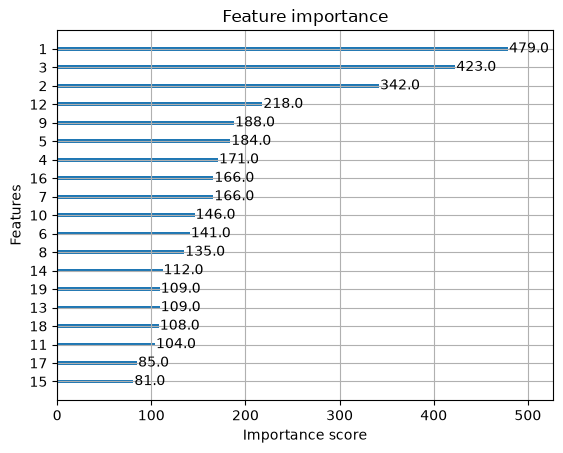

In [30]:
# analyze feature importance
import matplotlib.pyplot as plt
xgb.plot_importance(best_xgbr_model)
plt.show()

In [31]:
best_xgbr_model.get_booster().get_score(importance_type='gain')

{'1': 43793.07421875,
 '2': 431785.8125,
 '3': 1284653.875,
 '4': 2649.96533203125,
 '5': 25792.576171875,
 '6': 633.4424438476562,
 '7': 1926.0086669921875,
 '8': 623.0596313476562,
 '9': 971.3717651367188,
 '10': 7041.560546875,
 '11': 582.746337890625,
 '12': 98351.0546875,
 '13': 908.8842163085938,
 '14': 15335.0224609375,
 '15': 9548.2861328125,
 '16': 16252.0224609375,
 '17': 55587.3828125,
 '18': 25255.216796875,
 '19': 6089.57763671875}

Untuned Neural Network 

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2.4155 - val_loss: 0.7793
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9908 - val_loss: 0.5548
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8834 - val_loss: 0.6163
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7157 - val_loss: 0.4988
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7106 - val_loss: 0.5087
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6931 - val_loss: 0.4839
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6682 - val_loss: 0.4733
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6347 - val_loss: 0.4390
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6135 - val_loss: 0.4430
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5859 - val_loss: 0.4431
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5851 - val_loss: 0.4639
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5

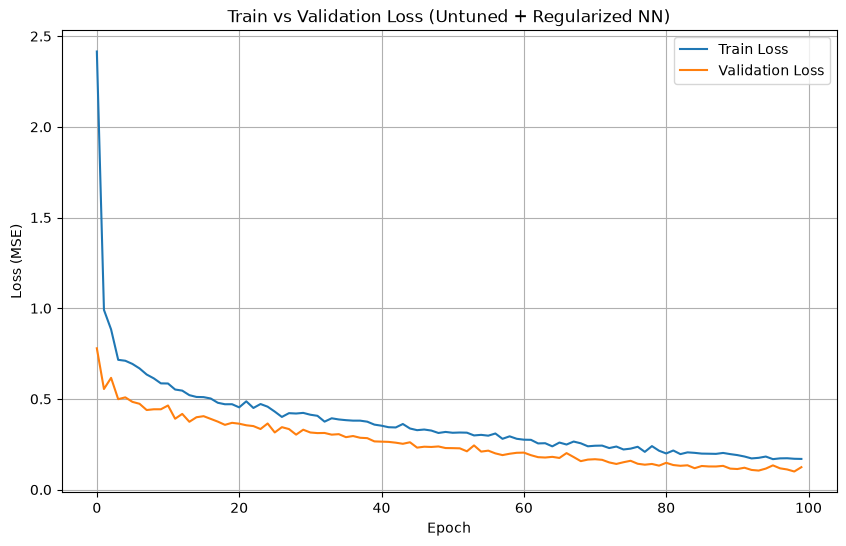

In [32]:
keras.utils.set_random_seed(42)

# define untuned but regularized model
model_untuned = keras.Sequential([
    keras.layers.Input(shape=(train_X_sc.shape[1],)),

    keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal',
                       kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(50, activation='relu', kernel_initializer='he_normal',
                       kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(10, activation='relu', kernel_initializer='he_normal',
                       kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(1, activation='linear')
])

# compile model
model_untuned.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

# early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# train the model
history_untuned = model_untuned.fit(
    nn_train_X, nn_train_y,
    validation_data=(nn_tune_X, nn_tune_y),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# predict and evaluate on validation set
val_pred_nn = model_untuned.predict(val_X_sc)
rmse_nn = np.sqrt(mean_squared_error(val_y_sc, val_pred_nn))
val_pred_nn_original = sc_y.inverse_transform(
    val_pred_nn.reshape(-1, 1)
).ravel()

rmse_nn_original = np.sqrt(
    mean_squared_error(
        val_y_raw.values.ravel(),
        val_pred_nn_original
    )
)

print(f"Basic NN RMSE (original): {rmse_nn_original:.4f}")
print(f"Basic Neural Network RMSE (validation): {rmse_nn:.4f}")

# plot train vs validation loss
plt.figure(figsize=(10, 6))
plt.plot(history_untuned.history['loss'], label='Train Loss')
plt.plot(history_untuned.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Train vs Validation Loss (Untuned + Regularized NN)')
plt.legend()
plt.grid(True)
plt.show()

Tuned Neural Network 

Trial 20 Complete [00h 00m 10s]
val_loss: 0.005374077241867781

Best val_loss So Far: 0.005374077241867781
Total elapsed time: 00h 03m 15s
Best hyperparameters:
{'num_layers': 1, 'units_0': 96, 'l2_0': 0.00028323885759729445, 'dropout_0': 0.2, 'learning_rate': 0.0069061594084365, 'units_1': 96, 'l2_1': 0.0013031284098441516, 'dropout_1': 0.5, 'units_2': 64, 'l2_2': 0.001115400261161857, 'dropout_2': 0.2}
Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4331 - mae: 0.4543 - val_loss: 0.1022 - val_mae: 0.1747
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1917 - mae: 0.2865 - val_loss: 0.0750 - val_mae: 0.1250
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1177 - mae: 0.2005 - val_loss: 0.0647 - val_mae: 0.1044
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0960 - mae: 0.1720 - val_loss: 0.0607 - val_mae: 0.0973
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0817 - mae: 0.1480 - val_loss: 0.0514 - val_mae: 0.0717
Epoch 6

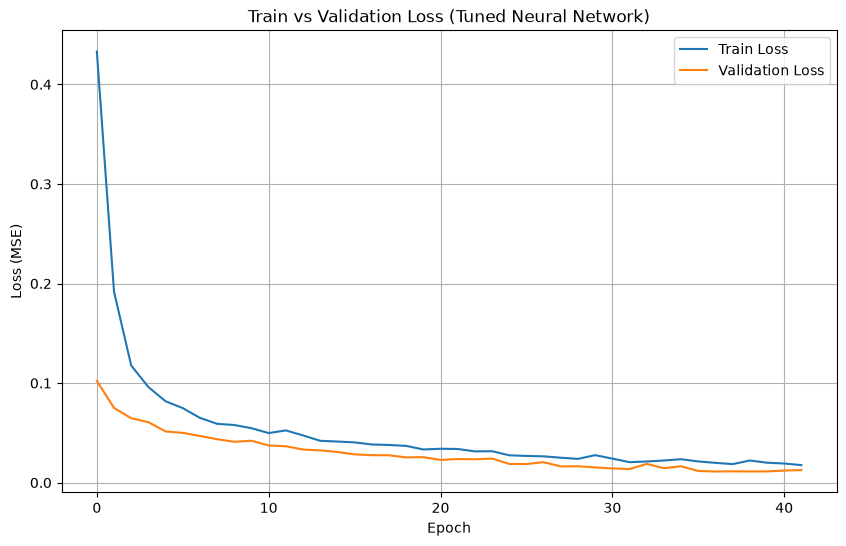

In [33]:
# clean up previous Keras Tuner directory if it exists
tuner_dir = 'keras_tuner_best'
if os.path.exists(tuner_dir):
    shutil.rmtree(tuner_dir)

# define the model builder function for Keras Tuner
def build_best_model(hp):
    model = keras.Sequential()
    
    # input layer
    model.add(layers.Input(shape=(train_X_sc.shape[1],)))
    
    # dynamic number of hidden layers (1 to 3)
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=128, step=32),
            activation='relu',
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(hp.Float(f'l2_{i}', 1e-5, 1e-2, sampling='log'))
        ))
        model.add(layers.Dropout(
            hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1)
        ))

    # output layer
    model.add(layers.Dense(1, activation='linear'))

    # compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
        ),
        loss='mse',
        metrics=['mae']
    )
    
    return model

# set up Keras Tuner random search
tuner = kt.RandomSearch(
    build_best_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='keras_tuner_best',
    project_name='best_model_tuning',
    seed=42,
    overwrite=True
)

# early stopping callback
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# search for best hyperparameters using proper validation set
tuner.search(
    nn_train_X, nn_train_y,
    validation_data=(nn_tune_X, nn_tune_y),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Get best hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hp.values)

# best model
best_model = tuner.hypermodel.build(best_hp)

# train a fresh model using the selected hyperparameters
# early stopping uses the tuning-validation subset
best_history = best_model.fit(
    nn_train_X, nn_train_y,
    validation_data=(nn_tune_X, nn_tune_y),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# predict and evaluate
val_pred_tuned = best_model.predict(val_X_sc)
rmse_tuned = np.sqrt(mean_squared_error(val_y_sc, val_pred_tuned))
val_pred_tuned_original = sc_y.inverse_transform(
    val_pred_tuned.reshape(-1, 1)
).ravel()

rmse_tuned_original = np.sqrt(
    mean_squared_error(
        val_y_raw.values.ravel(),
        val_pred_tuned_original
    )
)

print(f"Tuned NN RMSE (original): {rmse_tuned_original:.4f}")
print(f"Tuned Neural Network RMSE (validation): {rmse_tuned:.4f}")

# plot training vs. validation loss
plt.figure(figsize=(10, 6))
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Train vs Validation Loss (Tuned Neural Network)')
plt.legend()
plt.grid(True)
plt.show()

The training and tuning-validation loss curves are used to assess convergence and potential overfitting. Early stopping restores the weights with the lowest observed tuning-validation loss. A lower validation loss than training loss may partly reflect dropout and regularization; it does not establish that overfitting is absent.

The tuned neural network searches over one to three hidden layers, using ReLU activations, He initialization, dropout, and L2 regularization. The selected architecture and hyperparameters are reported by Keras Tuner. Predictive performance is evaluated separately on the held-out validation set.

Comparison of Tuned Neural Network and Benchmark Models

In [34]:
# compare models on the held-out validation set
benchmark_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'XGBoost',
        'Basic Neural Network',
        'Tuned Neural Network'
    ],
    'Validation RMSE (original units)': [
        rmse_lin_original,
        rmse_xgb_original,
        rmse_nn_original,
        rmse_tuned_original
    ]
})

# sort models by performance
benchmark_results = benchmark_results.sort_values(
    'Validation RMSE (original units)'
).reset_index(drop=True)

print(benchmark_results.round(4))

# identify best model
best_model_name = benchmark_results.loc[0, 'Model']

print(f"\nBest model: {best_model_name}")

                  Model  Validation RMSE (original units)
0               XGBoost                           16.9924
1  Tuned Neural Network                           19.3154
2     Linear Regression                           39.6243
3  Basic Neural Network                           62.9284

Best model: XGBoost


Predictions 

In [35]:
# select the best-performing model
if best_model_name == 'Linear Regression':
    test_pred_scaled = lin_reg.predict(test_X_sc)
    test_pred = sc_y.inverse_transform(
        test_pred_scaled.reshape(-1, 1)
    ).ravel()

elif best_model_name == 'XGBoost':
    test_pred = best_xgbr_model.predict(test_X)

elif best_model_name == 'Basic Neural Network':
    test_pred_scaled = model_untuned.predict(test_X_sc)
    test_pred = sc_y.inverse_transform(
        test_pred_scaled.reshape(-1, 1)
    ).ravel()

elif best_model_name == 'Tuned Neural Network':
    test_pred_scaled = best_model.predict(test_X_sc)
    test_pred = sc_y.inverse_transform(
        test_pred_scaled.reshape(-1, 1)
    ).ravel()

else:
    raise ValueError("Unknown model selected")

# create submission dataframe
submission_df = pd.DataFrame({
    'Row': np.arange(1, len(test_pred) + 1),
    'Predictions': test_pred
})

# save predictions
submission_df.to_csv('Test_Predictions.csv', index=False)

# inspect results
print(f"Model used: {best_model_name}")
print(submission_df.head())
print(submission_df['Predictions'].describe())

Model used: XGBoost
   Row  Predictions
0    1  -213.334076
1    2  -204.323059
2    3  -174.055557
3    4  -241.086807
4    5  -172.370422
count    625.000000
mean       5.200369
std      321.455261
min     -258.020691
25%     -234.383194
50%     -145.502930
75%      151.726074
max      935.564209
Name: Predictions, dtype: float64
